# DATA425 Lab 8: Convolutional Autoencoders and Variational Autoencoders

This lab extends the autoencoder idea in two directions.

First, we use a **convolutional autoencoder** so that the model keeps the spatial structure of images instead of immediately flattening them. This is useful for image reconstruction because nearby pixels carry meaningful local patterns.

Second, we build a **variational autoencoder**, or VAE. A VAE does not encode each input as one fixed code. Instead, it encodes each input as a distribution in latent space. That makes the latent space easier to sample from, which is why VAEs are useful for generation.

You will work through:

1. convolutional encoding and decoding,
2. pooling, downsampling, upsampling, and unpooling intuition,
3. why `Upsample + Conv` can produce cleaner decoder outputs than transposed convolution,
4. reconstruction with a convolutional autoencoder,
5. pixel-space interpolation compared with latent-space interpolation,
6. VAE latent distributions, sampling, reparameterization, and KL regularization,
7. generation by decoding random samples from $z \sim \mathcal{N}(0, I)$.

## Lecture map

Use this map to connect each section to the autoencoder and VAE lecture ideas.

| Lecture idea | What you will see in this lab |
|---|---|
| Autoencoder architecture | encoder to code to decoder models |
| Bottleneck and manifold intuition | latent codes with fewer dimensions than the input |
| Convolutional autoencoders | a convolutional encoder and an `Upsample + Conv` decoder |
| Pooling and upsampling | a small 4×4 matrix example |
| Interpolation | pixel interpolation compared with latent interpolation |
| Generative modelling | a VAE that samples from a latent distribution |
| Reparameterization trick | $z = \mu + \sigma\epsilon$, with $\epsilon \sim \mathcal{N}(0,I)$ |
| VAE loss | reconstruction term plus $\beta$ times KL divergence |

A good way to read the notebook is to track what the latent space is used for. In the convolutional autoencoder, the latent code is mainly for reconstruction. In the VAE, the latent space is also shaped so that we can sample from it.

In [ ]:
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


def set_seed(seed=425):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

set_seed(425)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load image tensors

The convolutional autoencoder uses image tensors with shape:

$$
N \times C \times H \times W.
$$

For the digits dataset, this is `N × 1 × 8 × 8`, because the images are grayscale and only 8×8 pixels.

The VAE later uses flattened vectors. That choice is not because VAEs require flattening. It is just a simple way to keep the model small and make a 2D latent space easy to inspect.

After the next cells, check both shapes:

- image tensors keep spatial structure for convolution,
- flattened tensors turn each image into a length-64 vector for the dense VAE.

In [ ]:
digits = load_digits()
images = digits.images.astype("float32") / 16.0
labels = digits.target.astype("int64")
X_img = images[:, None, :, :]       # N × 1 × 8 × 8
X_flat = images.reshape(len(images), -1)

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_img, labels, test_size=0.25, stratify=labels, random_state=425
)
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_train_img, y_train, test_size=0.20, stratify=y_train, random_state=425
)

X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_val_flat = X_val_img.reshape(len(X_val_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

print("Image tensor shape:", X_img.shape)
print("Flattened shape:", X_flat.shape)
print("Train/val/test:", X_train_img.shape, X_val_img.shape, X_test_img.shape)

Image tensor shape: (1797, 1, 8, 8)
Flattened shape: (1797, 64)
Train/val/test: (1077, 1, 8, 8) (270, 1, 8, 8) (450, 1, 8, 8)


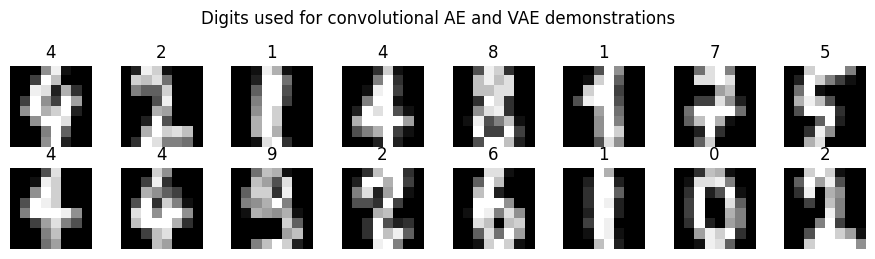

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, img, lab in zip(axes.ravel(), X_train_img[:16, 0], y_train[:16]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(lab))
    ax.axis("off")
plt.suptitle("Digits used for convolutional AE and VAE demonstrations")
plt.tight_layout()
plt.show()

## 2. Downsampling and upsampling

The encoder needs to compress the image, so it often downsamples spatial grids. Max pooling is one common downsampling method.

The decoder needs to expand the representation back to image size. One simple approach is nearest-neighbour upsampling: each value is repeated into a larger grid. After that, a convolutional layer can learn how to smooth and refine the result.

This notebook uses `Upsample + Conv` in the decoder. This is often easier to reason about than transposed convolution because the upsampling creates a regular grid first, then the convolution learns local structure on that grid. It can also help avoid checkerboard artifacts.

The next cell uses a tiny 4×4 matrix so you can see exactly what pooling and upsampling do.

In [ ]:
pool_input = torch.tensor([[[[1, 1, 2, 4],
                             [5, 6, 7, 8],
                             [3, 2, 1, 0],
                             [1, 2, 3, 4]]]], dtype=torch.float32)
pooled = nn.MaxPool2d(2, 2)(pool_input)
upsampled = nn.Upsample(scale_factor=2, mode="nearest")(pooled)

print("Original 4×4 matrix:")
print(pool_input[0, 0].numpy().astype(int))
print("\nAfter max pooling:")
print(pooled[0, 0].numpy().astype(int))
print("\nAfter nearest-neighbour upsampling:")
print(upsampled[0, 0].numpy().astype(int))

Original 4×4 matrix:
[[1 1 2 4]
 [5 6 7 8]
 [3 2 1 0]
 [1 2 3 4]]

After max pooling:
[[6 8]
 [3 4]]

After nearest-neighbour upsampling:
[[6 6 8 8]
 [6 6 8 8]
 [3 3 4 4]
 [3 3 4 4]]


## 3. Convolutional autoencoder

The convolutional autoencoder keeps image structure throughout most of the model.

The encoder compresses the spatial grid:

$$
8\times 8 \rightarrow 4\times 4 \rightarrow 2\times 2 \rightarrow z.
$$

The decoder reverses the process:

$$
z \rightarrow 2\times 2 \rightarrow 4\times 4 \rightarrow 8\times 8.
$$

The loss is mean squared error between the input image and its reconstruction.

When you read the model code, notice the two kinds of compression:

- max pooling reduces spatial size,
- the linear layer maps the final feature maps into a compact latent vector.

When you inspect the reconstructions, focus on whether the model captures the overall digit shape rather than every tiny pixel perfectly.

In [ ]:
def make_img_loader(X, batch_size=64, shuffle=True):
    tensor = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle)

train_img_loader = make_img_loader(X_train_img, 64, True)
val_img_tensor = torch.tensor(X_val_img, dtype=torch.float32, device=device)
test_img_tensor = torch.tensor(X_test_img, dtype=torch.float32, device=device)

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 8×8 -> 4×4
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 4×4 -> 2×2
        )
        self.to_latent = nn.Linear(16 * 2 * 2, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 16 * 2 * 2)
        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        return self.to_latent(h.flatten(start_dim=1))

    def decode(self, z):
        h = self.from_latent(z).view(-1, 16, 2, 2)
        return self.decoder_conv(h)

    def forward(self, x):
        return self.decode(self.encode(x))

conv_ae = ConvAutoencoder(latent_dim=8).to(device)
print(conv_ae)
print("Trainable parameters:", sum(p.numel() for p in conv_ae.parameters() if p.requires_grad))

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (to_latent): Linear(in_features=64, out_features=8, bias=True)
  (from_latent): Linear(in_features=8, out_features=64, bias=True)
  (decoder_conv): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)
Trainable parameters: 3577


In [ ]:
def train_conv_ae(model, train_loader, val_tensor, epochs=35, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total, n = 0.0, 0
        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            recon = model(xb)
            loss = F.mse_loss(recon, xb)
            loss.backward()
            optimizer.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        model.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(model(val_tensor), val_tensor).item()
        history.append({"epoch": epoch, "train_mse": total / n, "val_mse": val_loss})
        if epoch in {1, 2, 5, 10, 20, epochs}:
            print(f"epoch {epoch:02d} | train MSE {total / n:.4f} | val MSE {val_loss:.4f}")
    return pd.DataFrame(history)

conv_history = train_conv_ae(conv_ae, train_img_loader, val_img_tensor, epochs=35, lr=1e-3)

epoch 01 | train MSE 0.1788 | val MSE 0.1670
epoch 02 | train MSE 0.1484 | val MSE 0.1171
epoch 05 | train MSE 0.0798 | val MSE 0.0779
epoch 10 | train MSE 0.0700 | val MSE 0.0676
epoch 20 | train MSE 0.0467 | val MSE 0.0454
epoch 35 | train MSE 0.0361 | val MSE 0.0363


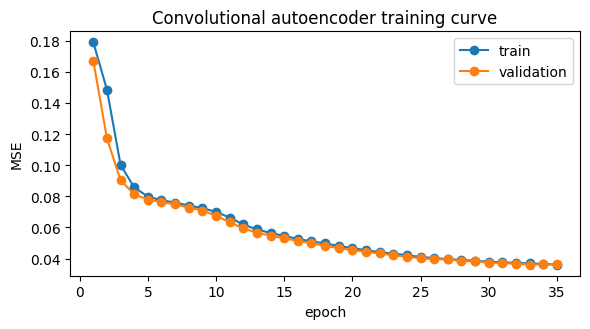

In [ ]:
plt.figure(figsize=(6, 3.4))
plt.plot(conv_history["epoch"], conv_history["train_mse"], marker="o", label="train")
plt.plot(conv_history["epoch"], conv_history["val_mse"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Convolutional autoencoder training curve")
plt.legend()
plt.tight_layout()
plt.show()

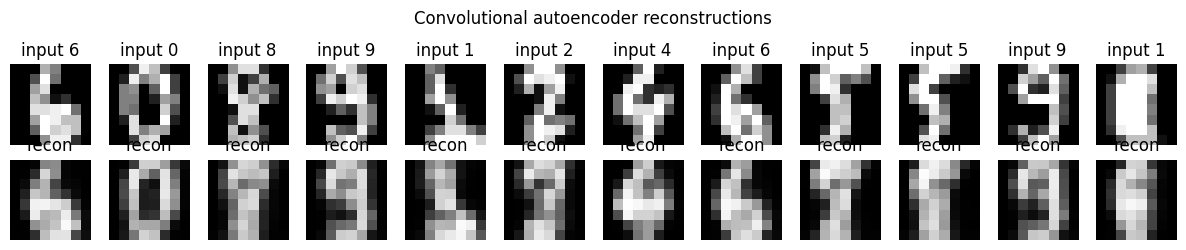

In [ ]:
conv_ae.eval()
with torch.no_grad():
    recon = conv_ae(test_img_tensor[:12]).cpu().numpy()

fig, axes = plt.subplots(2, 12, figsize=(12, 2.5))
for j in range(12):
    axes[0, j].imshow(X_test_img[j, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"input {y_test[j]}")
    axes[1, j].imshow(recon[j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("recon")
    for i in range(2):
        axes[i, j].axis("off")
plt.suptitle("Convolutional autoencoder reconstructions")
plt.tight_layout()
plt.show()

## 4. Pixel interpolation versus latent interpolation

Interpolation means moving smoothly between two examples.

Pixel interpolation directly averages the raw pixels:

$$
\alpha x_A + (1 - \alpha)x_B.
$$

Latent interpolation averages the learned codes and then decodes the result:

$$
\operatorname{decode}(\alpha z_A + (1 - \alpha)z_B).
$$

The difference is conceptual. Pixel interpolation knows nothing about what a digit is. It simply blends intensities. Latent interpolation uses the model's learned representation, so the path can stay closer to digit-like structure.

As you inspect the plot, compare the two rows. The latent row may look more like the decoder is trying to create plausible intermediate digits, while the pixel row is a direct visual blend.

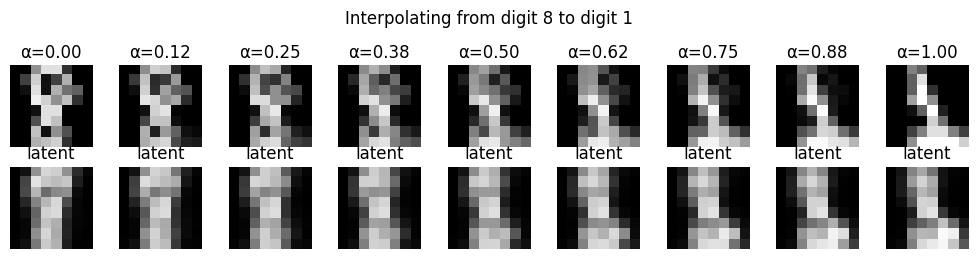

In [ ]:
# Pick two different digit examples.
idx_a = np.where(y_test == 1)[0][0]
idx_b = np.where(y_test == 8)[0][0]
x_a = torch.tensor(X_test_img[idx_a:idx_a+1], dtype=torch.float32, device=device)
x_b = torch.tensor(X_test_img[idx_b:idx_b+1], dtype=torch.float32, device=device)
alphas = torch.linspace(0, 1, steps=9, device=device).view(-1, 1)

with torch.no_grad():
    z_a = conv_ae.encode(x_a)
    z_b = conv_ae.encode(x_b)
    pixel_interp = alphas.view(-1, 1, 1, 1) * x_a + (1 - alphas.view(-1, 1, 1, 1)) * x_b
    z_interp = alphas * z_a + (1 - alphas) * z_b
    latent_interp = conv_ae.decode(z_interp)

fig, axes = plt.subplots(2, 9, figsize=(10, 2.6))
for j, alpha in enumerate(alphas.squeeze().cpu().numpy()):
    axes[0, j].imshow(pixel_interp[j, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"α={alpha:.2f}")
    axes[1, j].imshow(latent_interp[j, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("latent")
    axes[0, j].axis("off")
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("pixel", rotation=0, labelpad=20)
axes[1, 0].set_ylabel("latent", rotation=0, labelpad=20)
plt.suptitle("Interpolating from digit 8 to digit 1")
plt.tight_layout()
plt.show()

## 5. Variational autoencoder, or VAE

A standard autoencoder maps each input to a single code vector. A VAE maps each input to a distribution:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \operatorname{diag}(\sigma^2_\phi(x))).
$$

The encoder predicts two things for each input:

- $\mu$, the centre of the latent distribution,
- $\log(\sigma^2)$, a numerically stable way to represent the variance.

To sample while still allowing backpropagation, we use the reparameterization trick:

$$
z = \mu + \sigma \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I).
$$

This separates the random part, $\epsilon$, from the learned parameters, $\mu$ and $\sigma$.

The VAE loss is:

$$
\mathcal{L} = \mathcal{L}_{reconstruction} + \beta\, KL(q_\phi(z\mid x)\,||\,\mathcal{N}(0,I)).
$$

The reconstruction term asks the decoder to rebuild the image. The KL term pulls the learned latent distributions toward a standard Gaussian. This makes the latent space smoother and easier to sample from.

In [ ]:
train_flat_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_flat, dtype=torch.float32)), batch_size=64, shuffle=True
)
val_flat_tensor = torch.tensor(X_val_flat, dtype=torch.float32, device=device)
test_flat_tensor = torch.tensor(X_test_flat, dtype=torch.float32, device=device)

class VAE(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2):
        super().__init__()
        self.encoder_body = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta=0.2):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl, recon_loss, kl

vae = VAE(latent_dim=2).to(device)
print(vae)
print("Trainable parameters:", sum(p.numel() for p in vae.parameters() if p.requires_grad))

VAE(
  (encoder_body): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=32, out_features=2, bias=True)
  (logvar): Linear(in_features=32, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 12740


In [ ]:
def train_vae(model, train_loader, val_tensor, epochs=55, lr=1e-3, beta=0.2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0, "n": 0}
        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(xb)
            loss, recon_loss, kl = vae_loss(recon, xb, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            batch_size = xb.size(0)
            totals["loss"] += loss.item() * batch_size
            totals["recon"] += recon_loss.item() * batch_size
            totals["kl"] += kl.item() * batch_size
            totals["n"] += batch_size
        model.eval()
        with torch.no_grad():
            val_recon, val_mu, val_logvar = model(val_tensor)
            val_loss, val_recon_loss, val_kl = vae_loss(val_recon, val_tensor, val_mu, val_logvar, beta=beta)
        history.append({
            "epoch": epoch,
            "train_loss": totals["loss"] / totals["n"],
            "train_recon": totals["recon"] / totals["n"],
            "train_kl": totals["kl"] / totals["n"],
            "val_loss": val_loss.item(),
            "val_recon": val_recon_loss.item(),
            "val_kl": val_kl.item(),
        })
        if epoch in {1, 2, 5, 10, 25, epochs}:
            row = history[-1]
            print(
                f"epoch {epoch:02d} | train loss {row['train_loss']:.3f} "
                f"(recon {row['train_recon']:.3f}, KL {row['train_kl']:.3f}) | "
                f"val loss {row['val_loss']:.3f}"
            )
    return pd.DataFrame(history)

vae_history = train_vae(vae, train_flat_loader, val_flat_tensor, epochs=55, lr=1e-3, beta=0.2)

epoch 01 | train loss 42.381 (recon 42.367, KL 0.075) | val loss 39.952
epoch 02 | train loss 36.202 (recon 35.814, KL 1.937) | val loss 32.433
epoch 05 | train loss 28.063 (recon 27.527, KL 2.684) | val loss 27.819
epoch 10 | train loss 27.356 (recon 27.085, KL 1.355) | val loss 27.297
epoch 25 | train loss 25.457 (recon 25.079, KL 1.887) | val loss 25.208
epoch 55 | train loss 22.890 (recon 22.108, KL 3.910) | val loss 22.775


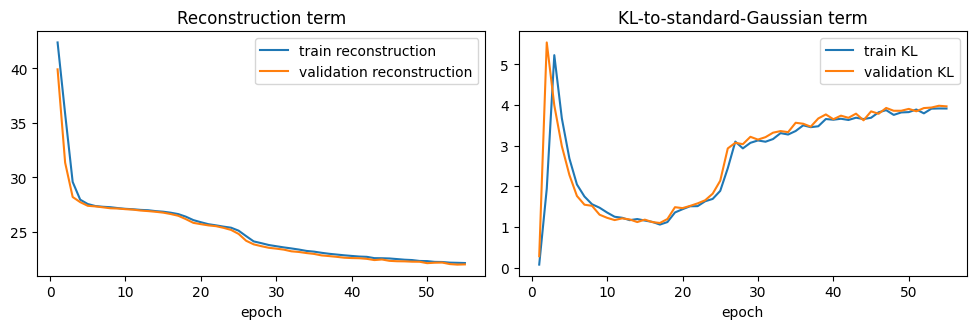

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(vae_history["epoch"], vae_history["train_recon"], label="train reconstruction")
ax[0].plot(vae_history["epoch"], vae_history["val_recon"], label="validation reconstruction")
ax[0].set_title("Reconstruction term")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(vae_history["epoch"], vae_history["train_kl"], label="train KL")
ax[1].plot(vae_history["epoch"], vae_history["val_kl"], label="validation KL")
ax[1].set_title("KL-to-standard-Gaussian term")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

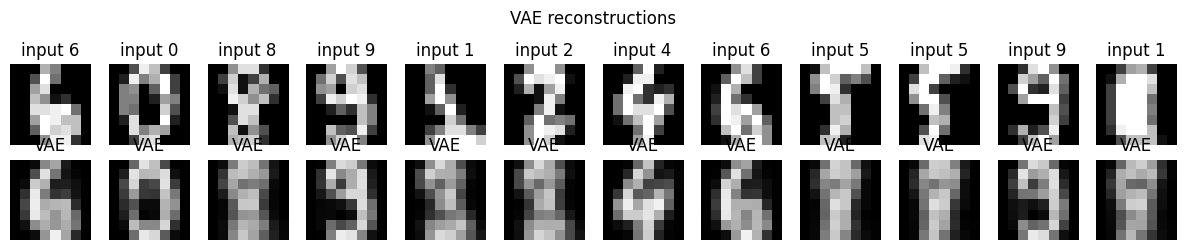

In [ ]:
vae.eval()
with torch.no_grad():
    vae_recon, mu, logvar = vae(test_flat_tensor[:12])
    vae_recon = vae_recon.cpu().numpy()

fig, axes = plt.subplots(2, 12, figsize=(12, 2.5))
for j in range(12):
    axes[0, j].imshow(X_test_flat[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"input {y_test[j]}")
    axes[1, j].imshow(vae_recon[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("VAE")
    for i in range(2):
        axes[i, j].axis("off")
plt.suptitle("VAE reconstructions")
plt.tight_layout()
plt.show()

## 6. Inspect and sample the VAE latent space

The VAE latent dimension is 2, so we can plot the latent mean $\mu(x)$ directly. Each point in the plot represents one image encoded by the VAE.

The KL term encourages these latent distributions to stay close to $\mathcal{N}(0, I)$. That is why we can later sample random points from a standard Gaussian and pass them through the decoder.

There are two generation demonstrations here:

1. decoding a regular grid of latent points, which shows how the latent space changes across directions,
2. decoding random points from $z \sim \mathcal{N}(0, I)$, which shows the model generating without an input image.

Generated images may be blurry. That is normal for a tiny VAE trained quickly on very small images. Focus on the mechanism: sample a latent point, then decode it.

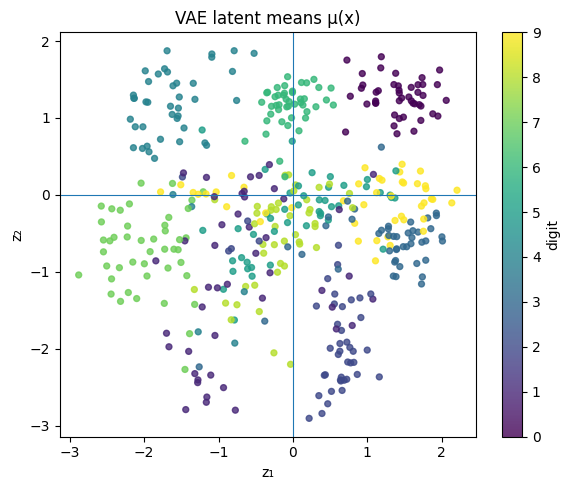

Mean of latent means: [-0.03381122 -0.1770765 ]
Standard deviation of latent means: [1.2315518 1.126795 ]


In [ ]:
vae.eval()
with torch.no_grad():
    mu_test, logvar_test = vae.encode(test_flat_tensor)
    mu_np = mu_test.cpu().numpy()

plt.figure(figsize=(6, 5))
scatter = plt.scatter(mu_np[:, 0], mu_np[:, 1], c=y_test, s=18, alpha=0.8)
plt.colorbar(scatter, ticks=range(10), label="digit")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("VAE latent means μ(x)")
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.tight_layout()
plt.show()

print("Mean of latent means:", mu_np.mean(axis=0))
print("Standard deviation of latent means:", mu_np.std(axis=0))

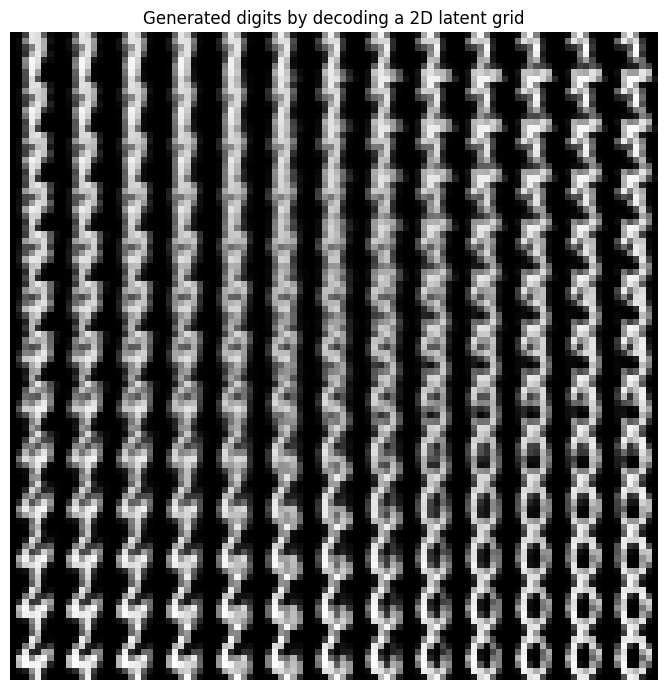

In [ ]:
# Decode a grid of z values. This is generation: no input image is provided.
vae.eval()
num = 13
grid_x = torch.linspace(-2.5, 2.5, steps=num)
grid_y = torch.linspace(-2.5, 2.5, steps=num)
canvas = np.zeros((num * 8, num * 8), dtype=np.float32)
with torch.no_grad():
    for i, y_coord in enumerate(grid_y):
        for j, x_coord in enumerate(grid_x):
            z = torch.tensor([[x_coord, y_coord]], dtype=torch.float32, device=device)
            decoded = vae.decode(z).cpu().numpy().reshape(8, 8)
            canvas[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8] = decoded

plt.figure(figsize=(7, 7))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Generated digits by decoding a 2D latent grid")
plt.tight_layout()
plt.show()

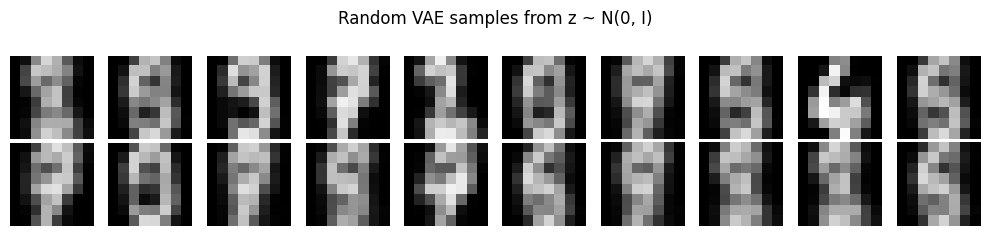

In [ ]:
# Random samples from the prior z ~ N(0, I).
with torch.no_grad():
    z = torch.randn(20, 2, device=device)
    samples = vae.decode(z).cpu().numpy().reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 10, figsize=(10, 2.4))
for ax, img in zip(axes.ravel(), samples):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Random VAE samples from z ~ N(0, I)")
plt.tight_layout()
plt.show()

## Lab takeaways

A convolutional autoencoder preserves spatial structure by using convolutional layers in the encoder and decoder. This is useful for image data because local pixel patterns matter. The latent code is a compressed representation that the decoder uses to reconstruct the input.

A VAE changes the autoencoder objective. It reconstructs inputs while also regularizing the latent distributions toward a simple reference distribution, usually a standard Gaussian. That regularized latent space is what lets us generate new images by sampling $z$ and decoding it.

### Suggested extensions

1. Change the convolutional autoencoder latent dimension from 8 to 2 or 32.
2. Replace `Upsample + Conv` with `ConvTranspose2d` and compare outputs.
3. Train the VAE with `beta=0.01`, `0.2`, and `1.0`. What changes in reconstruction quality and latent regularity?
4. Use a 3D VAE latent space and visualize pairwise projections.
5. Generate samples from points far outside $\mathcal{N}(0,I)$, such as `z=[8, 8]`. Do they still look valid?